# ⚖️ Decision Module & Threshold Sweep

This notebook demonstrates Phase 4.3. We will calculate the similarity scores for a subset of the SOCOFing dataset (both genuine and impostor pairs), sweep through various threshold values, and plot the False Accept Rate (FAR) and False Reject Rate (FRR) to find the Equal Error Rate (EER).

In [1]:
import os
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import transforms
from tqdm.notebook import tqdm

# Add project root to path
PROJECT_ROOT = Path(os.path.abspath('')).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_extraction.embedding import SiameseNetwork, extract_embedding
from src.matching.scorer import compute_embedding_score
from src.matching.decision import compute_rates, find_eer

DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'SOCOFing'
MODEL_PATH = PROJECT_ROOT / 'models' / 'siamese_model.pth'

## 1. Setup Data & Model

In [2]:
# Setup Model
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
siamese_model = SiameseNetwork(embedding_dim=128, pretrained=False).to(device)
if MODEL_PATH.exists():
    siamese_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("Loaded trained weights.")
siamese_model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_embedding(img_path):
    img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img_cv is None: return None
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_GRAY2RGB)
    tensor = transform(img_rgb)
    emb = extract_embedding(siamese_model, tensor, device).cpu().numpy()[0]
    return emb

Loaded trained weights.


## 2. Collect Scores (Deep Embeddings)
We will evaluate 100 genuine pairs and 100 impostor pairs.

In [3]:
genuine_scores = []
impostor_scores = []

real_dir = DATA_DIR / 'Real'
altered_dir = DATA_DIR / 'Altered' / 'Altered-Easy'

real_files = sorted(os.listdir(real_dir))[:50] # Take first 50 subjects for speed

print("Evaluating pairs...")
for f in tqdm(real_files):
    # Genuine Pair
    real_path = real_dir / f
    alt_name = f.replace('.BMP', '_CR.BMP')
    alt_path = altered_dir / alt_name
    
    emb1 = get_embedding(real_path)
    emb2 = get_embedding(alt_path)
    
    if emb1 is not None and emb2 is not None:
        score = compute_embedding_score(emb1, emb2)
        genuine_scores.append(score)
        
    # Impostor Pair (pair with the next file in the list)
    idx = real_files.index(f)
    next_f = real_files[(idx + 1) % len(real_files)]
    imp_path = real_dir / next_f
    
    emb3 = get_embedding(imp_path)
    if emb1 is not None and emb3 is not None:
        score = compute_embedding_score(emb1, emb3)
        impostor_scores.append(score)
        
print(f"Collected {len(genuine_scores)} genuine scores and {len(impostor_scores)} impostor scores.")

Evaluating pairs...


  0%|          | 0/50 [00:00<?, ?it/s]

Collected 49 genuine scores and 50 impostor scores.


## 3. Threshold Sweep & Plotting

Equal Error Rate (EER): 0.0506
Optimal Operating Threshold: 0.9596


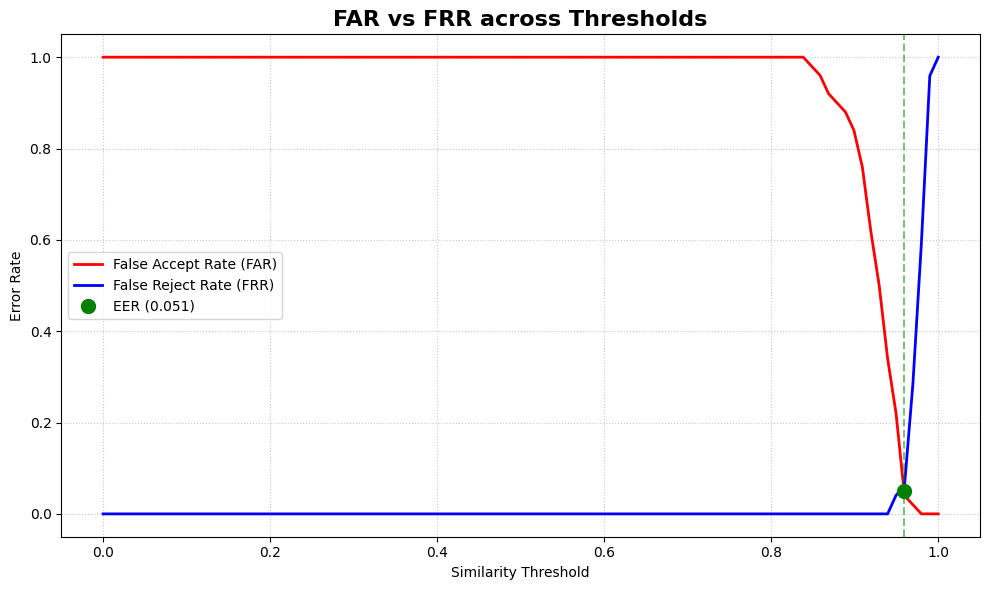

In [4]:
# Compute FAR and FRR across thresholds
thresholds = np.linspace(0.0, 1.0, 100)
far, frr = compute_rates(genuine_scores, impostor_scores, thresholds)

# Find EER
eer_val, opt_thresh = find_eer(far, frr, thresholds)

print(f"Equal Error Rate (EER): {eer_val:.4f}")
print(f"Optimal Operating Threshold: {opt_thresh:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, far, label='False Accept Rate (FAR)', color='red', linewidth=2)
plt.plot(thresholds, frr, label='False Reject Rate (FRR)', color='blue', linewidth=2)

# Mark EER
plt.plot(opt_thresh, eer_val, 'go', markersize=10, label=f'EER ({eer_val:.3f})')
plt.axvline(x=opt_thresh, color='green', linestyle='--', alpha=0.5)

plt.title('FAR vs FRR across Thresholds', fontsize=16, fontweight='bold')
plt.xlabel('Similarity Threshold')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.savefig(str(PROJECT_ROOT / 'data' / 'eer_threshold_sweep.png'), dpi=150)
plt.show()